출처: https://github.com/Gepetto/supaero2025/blob/main/3-invkine.ipynb

In [28]:
import pinocchio as pin
import numpy as np
import time
from numpy.linalg import pinv,inv,norm,svd,eig
from tiago_loader import loadTiago
import matplotlib.pylab as plt
from supaero2025.meshcat_viewer_wrapper import MeshcatVisualizer

# 1. Load a robot

In [29]:
robot = loadTiago()
viz = MeshcatVisualizer(robot)

/home/home/moving_robot/eunae/2_kinematics/tiago_loader.py:89: UserWarning: Deprecated member. Use Frame.parentJoint instead.
  JIDX = robot.model.frames[FIDX].parent
/home/home/moving_robot/eunae/2_kinematics/tiago_loader.py:97: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  pin.GeometryObject("axis_x", FIDX, JIDX, cyl, pin.SE3(X, X @ med + eff))
/home/home/moving_robot/eunae/2_kinematics/tiago_loader.py:102: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  pin.GeometryObject("axis_y", FIDX, JIDX, cyl, pin.SE3(Y, Y @ med + eff))
/home/home/moving_robot/eunae/2_kinematics/tiago_loader.py:107: UserWarning: This function has been marked as deprecated and will be removed in a future release.
  pin.GeometryObject("axis_z", FIDX, JIDX, cyl, pin.SE3(Z, Z @ med + eff))
/home/home/moving_robot/eunae/2_kinematics/tiago_loader.py:115: UserWarning: Deprecated member. Use Frame.parentJoint inste

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7015/static/


In [30]:
viz.viewer.jupyter_cell()

In [ ]:
# nq
'''
- 모바일 베이스: 1
- 머리: 2
- 팔: 7
- 바퀴: 2
- x, y, qw, qx, qy, qz (<- joint jumping)
'''

# nv
'''
- 모바일 베이스: 1
- 머리: 2
- 팔: 7
- 바퀴: 2
- x, y, y
'''

In [33]:
# robot.model.nv # number of velocities 15
robot.model.nq # number of joints 18

18

In [36]:
q = pin.randomConfiguration(robot.model) # random initial configuration
vq = np.random.rand(robot.model.nv)*2-1 # random initial velocity
DT = 1e-2   # time step
qnext = pin.integrate(robot.model,q,vq*DT)

In [38]:
for t in range(1000):
    q = pin.integrate(robot.model,q,vq*DT)
    viz.display(q)
    time.sleep(DT/10)

# 2. Forward kinematics

In [39]:
IDX_TOOL = robot.model.getFrameId('frametool')
IDX_BASIS = robot.model.getFrameId('framebasis')

In [40]:
robot.model.frames[IDX_TOOL]

Frame name: frametool paired to (parent joint/ parent frame)(9/52)
with relative placement wrt parent joint:
  R =
1 0 0
0 1 0
0 0 1
  p =    0    0 0.08
containing inertia:
  m = 0
  c = 0 0 0
  I = 
0 0 0
0 0 0
0 0 0

In [41]:
pin.framesForwardKinematics(robot.model,robot.data,q)

oMtool = robot.data.oMf[IDX_TOOL]
oRtool = oMtool.rotation; o_OT = oMtool.translation

In [42]:
oMtool

SE3(array([[ 0.17688923, -0.38974856, -0.90377334, -2.48308856],[-0.71053806, -0.68597616,  0.15675578, -0.55902653],[-0.6810623 ,  0.61443695, -0.39827298,  1.36897049],[ 0. ,  0. ,  0. ,  1. ]]))

In [44]:
oRtool

array([[ 0.17688923, -0.38974856, -0.90377334],
       [-0.71053806, -0.68597616,  0.15675578],
       [-0.6810623 ,  0.61443695, -0.39827298]])

In [45]:
o_OT

array([-2.48308856, -0.55902653,  1.36897049])

# 3. Compute Jacobians

In [46]:
# 프레임은 총 Local, Local World Aligned, World 이렇게 3가지가 있습니다.
# Pinocchio에서는 기본적으로 Local Frame으로 표현합니다.

tool_Jtool = pin.computeFrameJacobian(robot.model,robot.data,q,IDX_TOOL)
tool_Jtool3 = tool_Jtool[:3,:]
tool_vtool = tool_Jtool3 @ vq

In [47]:
tool_Jtool.shape

(6, 15)

In [48]:
o_Jtool3 = oRtool @ tool_Jtool3

In [49]:
# Sample between -0.001 and 0.001
EPS = 1e-3
dq = (np.random.rand(robot.model.nv)*2-1)*EPS

# q2 = q+dq
q2 = pin.integrate(robot.model,q,dq) 

pin.framesForwardKinematics(robot.model,robot.data,q)

# tool position for q
o_OT = robot.data.oMf[IDX_TOOL].translation.copy()

# tool position for q+dq
pin.framesForwardKinematics(robot.model,robot.data,q2)
o_OT2 = robot.data.oMf[IDX_TOOL].translation.copy()

print((o_OT2 - o_OT)/EPS)
print((o_Jtool3@dq/EPS)) 

[-0.28979238 -1.30670381 -0.84632889]
[-0.29047182 -1.30656736 -0.84630895]


# 4. Inverse kinematics for the moving the robot effector

In [65]:
# Goal placement, and integration in the viewer of the goal.
oMgoal = pin.SE3(pin.Quaternion(-0.5, 0.58, -0.39, 0.52).normalized().matrix(),
                np.array([1.2, .4, .7]))
viz.addBox('goal', [.1,.1,.1], [ .1,.1,.5, .6] )
viz.applyConfiguration('goal',oMgoal)

In [66]:
# Robot initial configuration.
q0 = np.array([ 0.  ,  0.  ,  1.  ,  0.  ,  0.18,  1.37, -0.24, -0.98,  0.98,
                0.  ,  0.  ,  0.  ,  0.  , -0.13,  0.  ,  0.  ,  0.  ,  0.  ])

## Methods of computing the Jacobian

In [67]:
q = q0.copy()
herr = [] # Log the value of the error between tool and goal.
# Loop on an inverse kinematics for 200 iterations.
for i in range(200):  # Integrate over 2 second of robot life

    # Run the algorithms that outputs values in robot.data
    pin.framesForwardKinematics(robot.model,robot.data,q)
    pin.computeJointJacobians(robot.model,robot.data,q)

    # Placement from world frame o to frame f oMtool
    oMtool = robot.data.oMf[IDX_TOOL]

    # 3D jacobian in world frame
    o_Jtool3 = pin.computeFrameJacobian(robot.model,robot.data,q,IDX_TOOL,pin.LOCAL_WORLD_ALIGNED)[:3,:]

    # vector from tool to goal, in world frame
    o_TG = oMgoal.translation - oMtool.translation
    
    # Control law by least square
    vq = pinv(o_Jtool3)@o_TG

    q = pin.integrate(robot.model,q, vq * DT)
    viz.display(q)
    time.sleep(1e-3)

    herr.append(o_TG) 

In [ ]:
q = q0.copy()
herr = [] # Log the value of the error between tool and goal.
# Loop on an inverse kinematics for 200 iterations.
for i in range(200):  # Integrate over 2 second of robot life

    # Run the algorithms that outputs values in robot.data
    pin.framesForwardKinematics(robot.model,robot.data,q)
    pin.computeJointJacobians(robot.model,robot.data,q)

    # Placement from world frame o to frame f oMtool
    oMtool = robot.data.oMf[IDX_TOOL]

    # 이전에 Local-World-Aligned 과 Local 자코비안의 상관관계를 공부함
    # J_local_world_aligned = o_R_local * J_local
    o_Jtool3 = oMtool.rotation @ pin.computeFrameJacobian(robot.model,robot.data,q,IDX_TOOL)[:3,:]

    # vector from tool to goal, in world frame
    o_TG = oMgoal.translation - oMtool.translation # offset

    # Control law by least square
    vq = pinv(o_Jtool3)@(o_TG)

    q = pin.integrate(robot.model,q, vq * DT)
    viz.display(q)
    time.sleep(1e-3)

    herr.append(o_TG) 


In [59]:
q = q0.copy()
herr = [] # Log the value of the error between tool and goal.
# Loop on an inverse kinematics for 200 iterations.
for i in range(400):  # Integrate over 2 second of robot life

    # Run the algorithms that outputs values in robot.data
    pin.framesForwardKinematics(robot.model,robot.data,q)
    pin.computeJointJacobians(robot.model,robot.data,q)

    # Placement from world frame o to frame f oMtool
    oMtool = robot.data.oMf[IDX_TOOL]

    tool_Jtool = pin.computeFrameJacobian(robot.model,robot.data,q,IDX_TOOL)
    o_TG = oMgoal.translation-oMtool.translation
    tool_TG = oMtool.rotation.T @ o_TG
    vq = pinv(tool_Jtool[:3,:]) @ tool_TG    

    q = pin.integrate(robot.model,q, vq * DT)
    viz.display(q)
    time.sleep(1e-3)

    herr.append(o_TG) 


In [70]:
tool_goal_log

array([ 0.00467505, -0.00161569,  0.00895273, -0.00295841,  0.01770378,
        0.02838674])

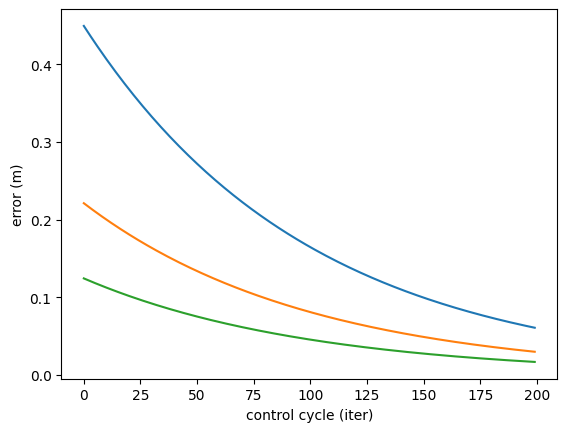

In [71]:
plt.plot(herr)
plt.xlabel('control cycle (iter)')
plt.ylabel('error (m)');